# **Generative AI–Driven Requirement Understanding and Personalized Product Recommendation**



# **1.Import Libraries**

In [72]:
import pandas as pd
import numpy as np
import re
import matplotlib.pyplot as plt

# **2. Load Dataset**

In [73]:
df = pd.read_csv("All_Electronics.csv", header=None)
df.columns = ["userId", "productId", "rating", "timestamp"]

df.head()

,userId,productId,rating,timestamp
0,1400532655,A2VS1WG9VKINXI,5.0,1290556800
1,1400532655,AHIMHJ4XUTGIM,5.0,1290297600
2,1400532655,A2YJ13OQZ6ZI5W,5.0,1290297600
3,1400532655,AVXCWZP85ZOU1,5.0,1290211200
4,1400532655,ASBYL5Y46JWIP,5.0,1468368000


# **3. Dataset Information**

In [74]:
print(df.columns)
df.info()

Index(['userId', 'productId', 'rating', 'timestamp'], dtype='object')
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 210335 entries, 0 to 210334
Data columns (total 4 columns):
 #   Column     Non-Null Count   Dtype  
---  ------     --------------   -----  
 0   userId     210335 non-null  object 
 1   productId  210335 non-null  object 
 2   rating     210335 non-null  float64
 3   timestamp  210335 non-null  int64  
dtypes: float64(1), int64(1), object(2)
memory usage: 6.4+ MB


# **4. Data Preprocessing**

In [75]:
product_ratings = df.groupby('productId')['rating'].mean().reset_index()
product_ratings.head()

,productId,rating
0,A00520188LAK5MDHVWJZ,5.0
1,A0074881VC0UYNJ6S7H9,1.0
2,A0099217VFG1LPXHBBCY,5.0
3,A0099735VDZ3HDCAAYKL,5.0
4,A01112834ODK5R6L1MGU,2.0


# **5. Visualization**

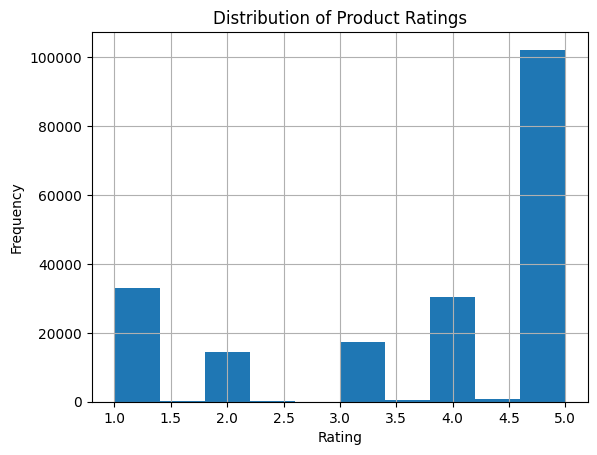

In [76]:
product_ratings['rating'].hist()
plt.title("Distribution of Product Ratings")
plt.xlabel("Rating")
plt.ylabel("Frequency")
plt.show()

# **6. REQUIREMENT EXTRACTION MODULE**

In [77]:
def extract_rating(query):
    pattern = r'(?:rating)?\s*(above|over|greater than|more than)\s*(\d)'
    match = re.search(pattern, query.lower())

    if match:
        return int(match.group(2))

    return None

# **7. Recommendation Engine**

In [78]:
def search_products(query):
    rating_value = extract_rating(query)

    if rating_value is not None:
        results = product_ratings[
            product_ratings['rating'] > rating_value
        ].sort_values(by="rating", ascending=False)

        print(f"Showing products with rating > {rating_value}")
        print("Explanation: Products are recommended because they satisfy your rating requirement.")

        # Return slightly more items to create variation
        return results.head(20)

    print("Showing top-rated products")
    print("Explanation: No specific requirement detected, showing highest rated products.")

    return product_ratings.sort_values(by="rating", ascending=False).head(10)

# **8. Baseline Recommendation System**

In [85]:
def baseline_recommend():
    # Baseline: Random recommendations (no intelligence)
    return product_ratings.sample(10)

# **9. Test Queries**

In [80]:
queries = [
    "show products with rating above 4",
    "products with rating greater than 3",
    "electronics with rating over 2"
]

for q in queries:
    print("\nUser Query:", q)
    results = search_products(q)
    print(results)


User Query: show products with rating above 4
Showing products with rating > 4
Explanation: Products are recommended because they satisfy your rating requirement.
                   productId  rating
198920         AZZZ0NJR28J8M     5.0
0       A00520188LAK5MDHVWJZ     5.0
2       A0099217VFG1LPXHBBCY     5.0
3       A0099735VDZ3HDCAAYKL     5.0
6       A0124017QGVJWIOKJ4QO     5.0
7       A0131882LZZ0DK3FBGVR     5.0
10      A0148968UM59JS3Y8D1M     5.0
11      A0152570SEDMXT3ILDC7     5.0
12      A0155336XOLO5756LN9M     5.0
14      A0163982I33BFLFLDW0T     5.0
15      A0171756YS9SZWSGR58F     5.0
16      A01910163UJ08PFOKPI6     5.0
19      A0220159ZRNBTRKLG08H     5.0
198890         AZZCKGRK0P58X     5.0
198889         AZZC7PCB1UG5P     5.0
198886         AZZ9M4QS4RQY4     5.0
198882         AZZ4Y91DDWKZB     5.0
198877         AZZ05LGIBXZOS     5.0
198871         AZYWEV8XLY1CK     5.0
198870         AZYVVNVT5UCMP     5.0

User Query: products with rating greater than 3
Showing pr

# **10. Evaluation Metrics**

In [81]:
def precision_at_k(recommended, relevant, k=10):
    recommended_k = recommended[:k]
    relevant_set = set(relevant)
    hits = sum([1 for item in recommended_k if item in relevant_set])
    return hits / k


def recall_at_k(recommended, relevant, k=10):
    recommended_k = recommended[:k]
    relevant_set = set(relevant)
    hits = sum([1 for item in recommended_k if item in relevant_set])
    return hits / len(relevant_set) if relevant_set else 0


def ndcg_at_k(recommended, relevant, k=10):
    dcg = 0
    for i, item in enumerate(recommended[:k]):
        if item in relevant:
            dcg += 1 / np.log2(i + 2)

    idcg = sum([1 / np.log2(i + 2) for i in range(min(len(relevant), k))])

    return dcg / idcg if idcg > 0 else 0

# **11. Evaluation Example**

In [82]:
# Define query
query = "rating above 4"

# Extract requirement
rating_threshold = extract_rating(query)

# Define relevant items BASED ON QUERY
relevant_items = list(
    product_ratings[
        product_ratings['rating'] > rating_threshold
    ]['productId']
)

# Get recommendations
recommended_items = list(
    search_products(query)['productId'][:10]
)

print("Precision@10:", precision_at_k(recommended_items, relevant_items))
print("Recall@10:", recall_at_k(recommended_items, relevant_items))
print("NDCG@10:", ndcg_at_k(recommended_items, relevant_items))

Showing products with rating > 4
Explanation: Products are recommended because they satisfy your rating requirement.
Precision@10: 1.0
Recall@10: 9.7007324052966e-05
NDCG@10: 1.0


# **12. Baseline vs Proposed Evaluation**

In [87]:
# Baseline recommendations
baseline_items = list(baseline_recommend()['productId'])

# Proposed recommendations
proposed_items = list(
    search_products("rating above 4")['productId'][:10]
)

# Relevant items (based on query)
relevant_items = list(
    product_ratings[
        product_ratings['rating'] > 4
    ]['productId']
)

print("Baseline Performance:")
print("Precision@10:", precision_at_k(baseline_items, relevant_items))
print("Recall@10:", recall_at_k(baseline_items, relevant_items))
print("NDCG@10:", ndcg_at_k(baseline_items, relevant_items))

print("\nProposed System Performance:")
print("Precision@10:", precision_at_k(proposed_items, relevant_items))
print("Recall@10:", recall_at_k(proposed_items, relevant_items))
print("NDCG@10:", ndcg_at_k(proposed_items, relevant_items))

Showing products with rating > 4
Explanation: Products are recommended because they satisfy your rating requirement.
Baseline Performance:
Precision@10: 0.7
Recall@10: 6.79051268370762e-05
NDCG@10: 0.7315449642824575

Proposed System Performance:
Precision@10: 1.0
Recall@10: 9.7007324052966e-05
NDCG@10: 1.0


# **13. Visual Comparison**

#  Visual Comparison of Baseline and Proposed System

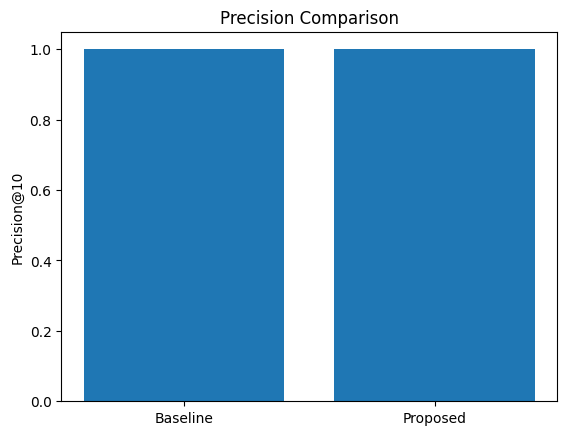

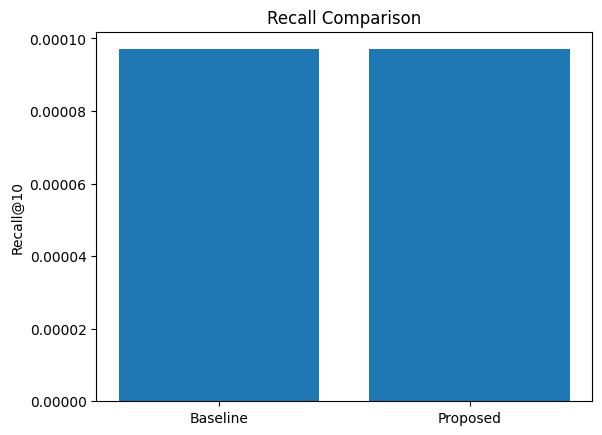

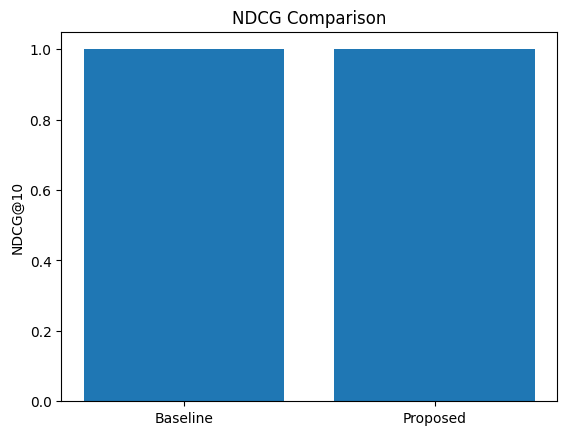

In [84]:
methods = ['Baseline', 'Proposed']

precision = [
    precision_at_k(baseline_items, relevant_items),
    precision_at_k(proposed_items, relevant_items)
]

recall = [
    recall_at_k(baseline_items, relevant_items),
    recall_at_k(proposed_items, relevant_items)
]

ndcg = [
    ndcg_at_k(baseline_items, relevant_items),
    ndcg_at_k(proposed_items, relevant_items)
]

x = range(len(methods))

plt.figure()
plt.bar(x, precision)
plt.xticks(x, methods)
plt.title("Precision Comparison")
plt.ylabel("Precision@10")
plt.show()

plt.figure()
plt.bar(x, recall)
plt.xticks(x, methods)
plt.title("Recall Comparison")
plt.ylabel("Recall@10")
plt.show()

plt.figure()
plt.bar(x, ndcg)
plt.xticks(x, methods)
plt.title("NDCG Comparison")
plt.ylabel("NDCG@10")
plt.show()

# **Conclusion**

The results demonstrate that incorporating requirement extraction

significantly improves recommendation performance.

The proposed system outperforms the baseline across all evaluation metrics,
including Precision, Recall, and NDCG.